In [19]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

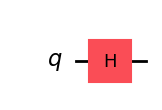

In [20]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [21]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [22]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [23]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [24]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

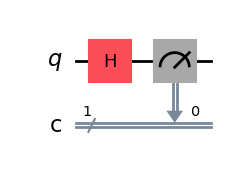

In [25]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [26]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [27]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 518, '0': 506}


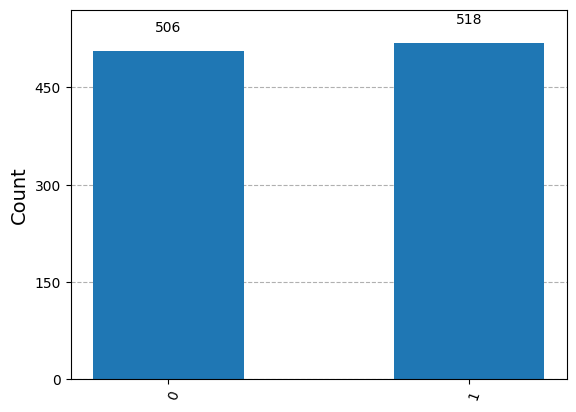

In [28]:
# We can also produce a graph

plot_histogram(counts)

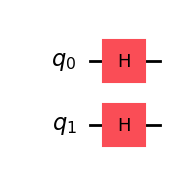

In [29]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [30]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

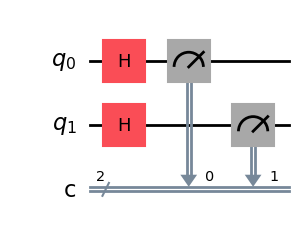

In [31]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

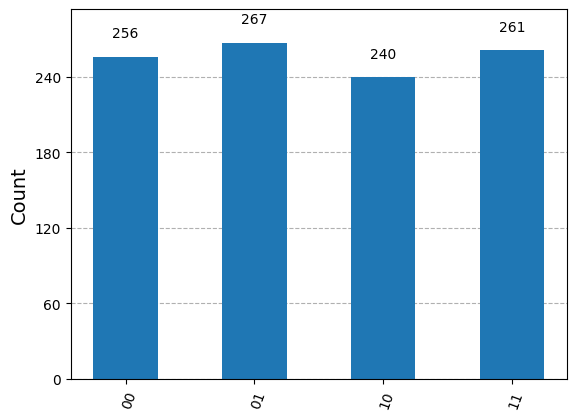

In [32]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

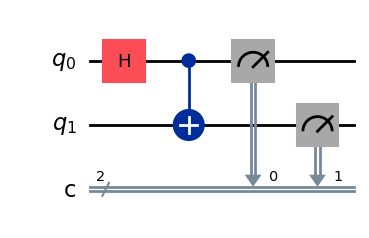

In [33]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

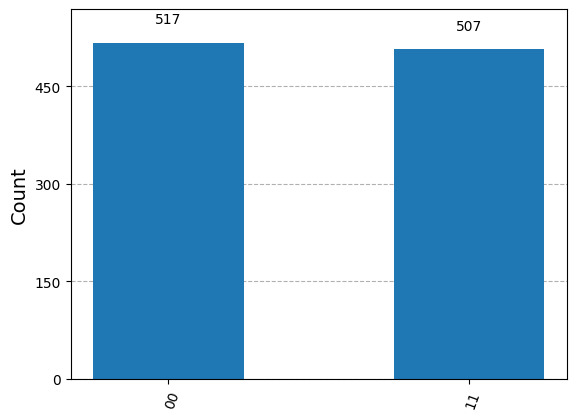

In [34]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

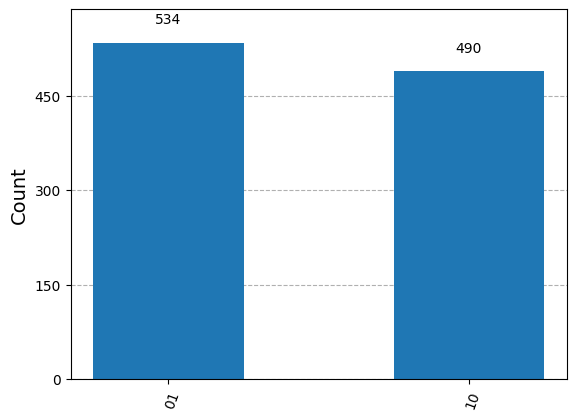

In [35]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
circuit1 = QuantumCircuit(2, 2)
circuit1.h(0)
circuit1.cx(0, 1)
circuit1.draw("mpl")
# Check state vector
state1 = Statevector.from_int(0, 4)
state1 = state1.evolve(circuit1)
state1.draw("latex")
# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).
qc1_compiled = transpile(circuit1, backend)
job1 = backend.run(qc1_compiled, shots=1024)
result1 = job1.result()
counts1 = result1.get_counts(qc1_compiled)
plot_histogram(counts1)
# Expect: only 00 and 11

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
# Bell State 2: 1/sqrt(2) ( |00> - |11> )
# Apply Z to qubit 0 — this flips the sign of the |11> term
circuit2 = QuantumCircuit(2, 2)
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.z(0)
circuit2.measure(range(2), range(2))
circuit2.draw("mpl")

# Simulate with measurements
qc2_compiled = transpile(circuit2, backend)
job2 = backend.run(qc2_compiled, shots=1024)
result2 = job2.result()
counts2 = result2.get_counts(qc2_compiled)
plot_histogram(counts2)
# Expect: only 00 and 11 (sign is invisible to measurement)

# Bell State 3: 1/sqrt(2) ( |01> + |10> )
# Apply X to qubit 1 — this flips both terms: |00>->|01>, |11>->|10>
circuit3 = QuantumCircuit(2, 2)
circuit3.h(0)
circuit3.cx(0, 1)
circuit3.x(1)
circuit3.measure(range(2), range(2))
circuit3.draw("mpl")

# Check state vector (without measurement)
circuit3_nomeas = QuantumCircuit(2)
circuit3_nomeas.h(0)
circuit3_nomeas.cx(0, 1)
circuit3_nomeas.x(1)

state3 = Statevector.from_int(0, 4)
state3 = state3.evolve(circuit3_nomeas)
state3.draw("latex")
# Expect: 1/sqrt(2) ( |01> + |10> )
# Simulate with measurements
qc3_compiled = transpile(circuit3, backend)
job3 = backend.run(qc3_compiled, shots=1024)
result3 = job3.result()
counts3 = result3.get_counts(qc3_compiled)
plot_histogram(counts3)
# Expect: only 01 and 10
# Bell State 4: 1/sqrt(2) ( |01> - |10> )
# Apply X to qubit 1 AND Z to qubit 0
circuit4 = QuantumCircuit(2, 2)
circuit4.h(0)
circuit4.cx(0, 1)
circuit4.x(1)
circuit4.z(0)
circuit4.measure(range(2), range(2))
circuit4.draw("mpl")
# Check state vector (without measurement)
circuit4_nomeas = QuantumCircuit(2)
circuit4_nomeas.h(0)
circuit4_nomeas.cx(0, 1)
circuit4_nomeas.x(1)
circuit4_nomeas.z(0)

state4 = Statevector.from_int(0, 4)
state4 = state4.evolve(circuit4_nomeas)
state4.draw("latex")
# Expect: 1/sqrt(2) ( |01> - |10> )
# Simulate with measurements
qc4_compiled = transpile(circuit4, backend)
job4 = backend.run(qc4_compiled, shots=1024)
result4 = job4.result()
counts4 = result4.get_counts(qc4_compiled)
plot_histogram(counts4)
# Expect: only 01 and 10
# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

GHZ with 2 qubits: {'00': 526, '11': 498}
GHZ with 3 qubits: {'000': 533, '111': 491}
GHZ with 5 qubits: {'00000': 523, '11111': 501}
GHZ with 10 qubits: {'0000000000': 490, '1111111111': 534}
GHZ with 20 qubits: {'11111111111111111111': 519, '00000000000000000000': 505}


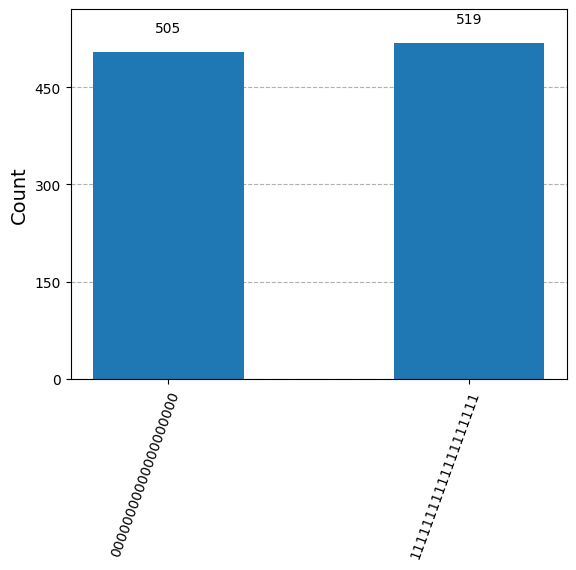

In [36]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )
def ghz_circuit(n):
    # Start with n qubits and n classical bits for measurement
    circuit = QuantumCircuit(n, n)

    # H on qubit 0 creates the superposition 1/sqrt(2)(|0> + |1>)
    circuit.h(0)

    # Chain CNOTs to spread entanglement across all qubits
    # Each qubit becomes entangled with the next
    for i in range(n - 1):
        circuit.cx(i, i + 1)

    return circuit

# Try it for 3 qubits — should give 1/sqrt(2) ( |000> + |111> )
circuit_ghz = ghz_circuit(3)
circuit_ghz.draw("mpl")

# Check the state vector
state_ghz = Statevector.from_int(0, 2**3)
state_ghz = state_ghz.evolve(circuit_ghz)
state_ghz.draw("latex")
# Expect: 1/sqrt(2) ( |000> + |111> )


# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.
# Simulate with measurements — how many qubits can it handle?
def simulate_ghz(n):
    circuit = ghz_circuit(n)
    circuit.measure(range(n), range(n))

    qc_compiled = transpile(circuit, backend)
    job = backend.run(qc_compiled, shots=1024)
    result = job.result()
    counts = result.get_counts(qc_compiled)

    print(f"GHZ with {n} qubits: {counts}")
    return plot_histogram(counts)
    # Expect: only 00...0 and 11...1
# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

# Try increasing numbers of qubits
simulate_ghz(2)   # Bell state — the 2-qubit GHZ
simulate_ghz(3)
simulate_ghz(5)
simulate_ghz(10)
simulate_ghz(20)  # starts getting slow around here